In [1]:
# !pip uninstall gensim --yes
# !pip install gensim==3.8.1
# !pip install deeprobust==0.2.9
# !pip install torch_geometric
# !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html

In [2]:
from deeprobust.graph.data import Dpr2Pyg, Pyg2Dpr
from deeprobust.graph.data import Dataset as DRDataset
import torch
from torch_geometric.data import Data
import numpy as np
from deeprobust.graph.data import Dataset, PrePtbDataset, PtbDataset
from deeprobust.graph.defense import GCN, RGCN, ProGNN, SimPGCN, GCNSVD, GCNJaccard
from deeprobust.graph.global_attack import Metattack, DICE, Random, PGDAttack
from scipy.sparse import csr_matrix
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.transforms import Compose
from torch_geometric.datasets import Amazon
from torch_geometric.transforms.random_node_split import RandomNodeSplit
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score

from torch_geometric.utils import negative_sampling
from torch_geometric.utils import train_test_split_edges

from copy import deepcopy
import torch.nn as nn
from IPython.display import Javascript  # Restrict height of output cell.
import matplotlib.pyplot as plt

from GSage import GSAGE
from GSaint import GSAINT
from GAT import GAT

In [3]:
seed = 15
ptb_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rates = [0.025, 0.05]
# ptb_rate = 0.25
# ptb_rate1 = 0.15
dataset = 'citeseer'
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [4]:
data = DRDataset(root='/tmp/', name=dataset, setting='prognn')
adj, features, labels = data.adj, data.features, data.labels
idx_train, idx_val, idx_test = data.idx_train, data.idx_val, data.idx_test
idx_unlabeled = np.union1d(idx_val, idx_test)
idx_unlabeled = np.union1d(idx_val, idx_test)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# budget = int(ptb_rate * (adj.todense().sum() // 2))
# print(budget)
# budget1 = int(ptb_rate1 * (adj.todense().sum() // 2))
# print(budget1)

Loading citeseer dataset...
Selecting 1 largest connected components
Dowloading from https://raw.githubusercontent.com/ChandlerBang/Pro-GNN/master/splits/citeseer_prognn_splits.json to /tmp/citeseer_prognn_splits.json


In [5]:
np.save(f'/tmp/{dataset}_adj.npy',adj.todense())

In [6]:
np.save(f'/tmp/{dataset}_features.npy',features.todense())

In [7]:
np.save(f'/tmp/{dataset}_labels.npy',labels)

In [8]:
np.save(f'/tmp/{dataset}_idx_test',idx_test)

# Metattack

## GAT

In [9]:
surrogate5 = GAT(nfeat=features.shape[1],
      nhid=8, heads=8,
      nclass=labels.max().item() + 1,
      dropout=0.5, device=device)
surrogate5 = surrogate5.to(device)

pyg_data = Dpr2Pyg(data)
surrogate5.fit(pyg_data, verbose=True) # train with earlystopping
surrogate5.test()

Processing...
/home/wcorcoran/anaconda3/envs/mesp/lib/python3.8/site-packages/deeprobust/graph/data/pyg_dataset.py:48: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  edge_index = torch.LongTensor(dpr_data.adj.nonzero())
Done!
/home/wcorcoran/anaconda3/envs/mesp/lib/python3.8/site-packages/torch_geometric/data/in_memory_dataset.py:157: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


=== training GAT model ===
Epoch 0, training loss: 1.8220605850219727
Epoch 10, training loss: 0.5069877505302429
Epoch 20, training loss: 0.3469322621822357
Epoch 30, training loss: 0.31078752875328064
Epoch 40, training loss: 0.28650766611099243
Epoch 50, training loss: 0.39581498503685
Epoch 60, training loss: 0.23617719113826752
Epoch 70, training loss: 0.2284516990184784
Epoch 80, training loss: 0.3140437602996826
Epoch 90, training loss: 0.3328787684440613
Epoch 100, training loss: 0.2972206175327301
=== early stopping at 106, loss_val = 0.840660572052002 ===
Test set results: loss= 0.8618 accuracy= 0.7305


0.7304502369668247

In [10]:
surrogate5.eval()
preds=surrogate5.predict()
_, predicted_classes = torch.max(preds, 1)  # Returns values, indices; we need indices

# Step 3: Subset for test nodes
test_preds = predicted_classes[idx_test].cpu().numpy()
test_labels = labels[idx_test]

# Step 4: Calculate accuracy
correct = (test_preds == test_labels).sum().item()  # Count correct predictions
total = idx_test.shape[0]  # Total number of test nodes
test_accuracy = correct / total
benchmark_clean = test_accuracy

print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7304502369668247


In [11]:
from copy import deepcopy

# ptb_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
gat_results = []

for ptb in ptb_rates:
  budget = int(ptb * (adj.todense().sum() // 2))
  # Setup Attack Model
  model = Metattack(surrogate5, nnodes=adj.shape[0], feature_shape=features.shape,
          attack_structure=True, attack_features=False, device=device, lambda_=0).to(device)
  # Attack
  model.attack(features, adj, labels, idx_train, idx_unlabeled, n_perturbations=budget, ll_constraint=False)
  modified_adj = model.modified_adj # modified_adj is a torch.tensor
  modified_adj = modified_adj.cpu().numpy()
  modified_adj = csr_matrix(modified_adj)

  perturbed_adj = deepcopy(modified_adj)

  data_copied = deepcopy(data)
  data_copied.adj = modified_adj

  atk_model = GAT(nfeat=features.shape[1],
        nhid=8, heads=8,
        nclass=labels.max().item() + 1,
        dropout=0.5, device=device)
  atk_model = surrogate5.to(device)
  atk_model.fit(Dpr2Pyg(data_copied), patience=100, verbose=True)

  atk_acc = atk_model.test()

  print("accuracy: ", atk_acc)
  print("benchmark change: ", atk_acc - benchmark_clean)
  gat_results.append(atk_acc - benchmark_clean)

Perturbing graph:   0%|          | 0/183 [00:00<?, ?it/s]

GCN loss on unlabled data: 1.1803910732269287
GCN acc on unlabled data: 0.7030015797788309
attack loss: 0.47382453083992004


Perturbing graph:   1%|          | 1/183 [00:02<07:37,  2.51s/it]

GCN loss on unlabled data: 1.2260732650756836
GCN acc on unlabled data: 0.6998420221169036
attack loss: 0.4644056260585785


Perturbing graph:   1%|          | 2/183 [00:04<06:12,  2.06s/it]

...

GCN loss on unlabled data: 3.3255701065063477
GCN acc on unlabled data: 0.44023170089520797
attack loss: 5.257898330688477


Perturbing graph: 100%|█████████▉| 1099/1100 [26:32<00:01,  1.47s/it]

GCN loss on unlabled data: 2.892732620239258
GCN acc on unlabled data: 0.46866771985255395
attack loss: 4.629292964935303


Perturbing graph: 100%|██████████| 1100/1100 [26:33<00:00,  1.45s/it]
Processing...
Done!


=== training GAT model ===
Epoch 0, training loss: 1.806922435760498
Epoch 10, training loss: 0.5881398320198059
Epoch 20, training loss: 0.3543618321418762
Epoch 30, training loss: 0.2500058710575104
Epoch 40, training loss: 0.20047079026699066
Epoch 50, training loss: 0.23924297094345093
Epoch 60, training loss: 0.2276490479707718
Epoch 70, training loss: 0.23166202008724213
Epoch 80, training loss: 0.12538744509220123
Epoch 90, training loss: 0.14479447901248932
Epoch 100, training loss: 0.18061146140098572
=== early stopping at 104, loss_val = 1.2337863445281982 ===
Test set results: loss= 1.2243 accuracy= 0.6297
accuracy:  0.629739336492891
benchmark change:  -0.1007109004739336


## GSAINT

In [12]:
# Setup Surrogate model
surrogate_saint = GSAINT(nfeat=features.shape[1], nhid=64, nclass=labels.max().item()+1, dropout=0, with_bias=True, device=device).to(device)
surrogate_saint.fit(data, patience=100, verbose=True)

Processing...
Done!
Compute GraphSAINT normalization: : 220562it [00:01, 153237.21it/s]                          


=== training GSAINT model ===
Epoch 0, training loss: 0.02857412025332451
Epoch 10, training loss: 0.0010273586958646774
Epoch 20, training loss: 0.0009409733465872705
Epoch 30, training loss: 0.0008276187581941485
Epoch 40, training loss: 0.0009173981961794198
Epoch 50, training loss: 0.0008865534910000861
Epoch 60, training loss: 0.0009329338208772242
Epoch 70, training loss: 0.0010454864241182804
Epoch 80, training loss: 0.0009554029093123972
Epoch 90, training loss: 0.0009437109110876918
Epoch 100, training loss: 0.0009924902115017176
=== early stopping at 109, loss_val = 0.6946502327919006 ===


In [13]:
preds=surrogate_saint.predict()
_, predicted_classes = torch.max(preds, 1)  # Returns values, indices; we need indices

# Step 3: Subset for test nodes
test_preds = predicted_classes[idx_test].cpu().numpy()
test_labels = labels[idx_test]

# Step 4: Calculate accuracy
correct = (test_preds == test_labels).sum().item()  # Count correct predictions
total = idx_test.shape[0]  # Total number of test nodes
test_accuracy = correct / total

print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7511848341232228


In [14]:
benchmark_clean = test_accuracy

In [15]:
from copy import deepcopy

gsaint_results = []

for ptb in ptb_rates:
  torch.cuda.empty_cache()
  budget = int(ptb * (adj.todense().sum() // 2))
  # Setup Attack Model
  model = Metattack(surrogate_saint, nnodes=adj.shape[0], feature_shape=features.shape,
          attack_structure=True, attack_features=False, device=device, lambda_=0).to(device)
  # Attack
  model.attack(features, adj, labels, idx_train, idx_unlabeled, n_perturbations=budget, ll_constraint=False)
  modified_adj = model.modified_adj # modified_adj is a torch.tensor
  modified_adj = modified_adj.cpu().numpy()
  modified_adj = csr_matrix(modified_adj)

  perturbed_adj = deepcopy(modified_adj)
  data_copied = deepcopy(data)
  data_copied.adj = modified_adj
  atk_model = GSAINT(nfeat=features.shape[1], nhid=64, nclass=labels.max().item()+1, dropout=0, with_bias=True, device=device).to(device)
  atk_model.fit(data_copied, patience=100, verbose=True)

  atk_acc = atk_model.test()
  print("accuracy: ", atk_acc)
  print("benchmark change: ", atk_acc - benchmark_clean)
  gsaint_results.append(atk_acc - benchmark_clean)


Perturbing graph:   0%|          | 0/183 [00:00<?, ?it/s]

GCN loss on unlabled data: 1.123850703239441
GCN acc on unlabled data: 0.7261716692996313
attack loss: 0.3387753665447235


Perturbing graph:   1%|          | 1/183 [00:01<04:01,  1.33s/it]

GCN loss on unlabled data: 1.1176846027374268
GCN acc on unlabled data: 0.723012111637704
attack loss: 0.3345676362514496


Perturbing graph:   1%|          | 2/183 [00:02<04:03,  1.34s/it]

...

GCN loss on unlabled data: 6.3647780418396
GCN acc on unlabled data: 0.2912058978409689
attack loss: 6.118872165679932


Perturbing graph: 100%|█████████▉| 1099/1100 [26:45<00:01,  1.38s/it]

GCN loss on unlabled data: 6.486642360687256
GCN acc on unlabled data: 0.29331226961558715
attack loss: 6.253862380981445


Perturbing graph: 100%|██████████| 1100/1100 [26:46<00:00,  1.46s/it]
Processing...
Done!
Compute GraphSAINT normalization: : 220835it [00:00, 930169.79it/s]                          


=== training GSAINT model ===
Epoch 0, training loss: 0.050290390849113464
Epoch 10, training loss: 0.0011625482002273202
Epoch 20, training loss: 0.0011020689271390438
Epoch 30, training loss: 0.0011404883116483688
Epoch 40, training loss: 0.00282715680077672
Epoch 50, training loss: 0.0009609489352442324
Epoch 60, training loss: 0.001066379016265273
Epoch 70, training loss: 0.0010738191194832325
Epoch 80, training loss: 0.001079855253919959
Epoch 90, training loss: 0.0010931629221886396
Epoch 100, training loss: 0.0010813218541443348
Epoch 110, training loss: 0.0010769935324788094
Epoch 120, training loss: 0.0010723869781941175
Epoch 130, training loss: 0.0010620587272569537
Epoch 140, training loss: 0.001064535230398178
Epoch 150, training loss: 0.0010603736154735088
=== early stopping at 159, loss_val = 0.8418077230453491 ===
accuracy:  0.6842417061611374
benchmark change:  -0.06694312796208535


## GSAGE

In [16]:
# Setup Surrogate model
surrogate_sage = GSAGE(nfeat=features.shape[1], nhid=64, nclass=labels.max().item()+1, dropout=0, with_bias=True, device=device).to(device)
surrogate_sage.fit(data, patience=100, verbose=True)

Processing...
Done!
/home/wcorcoran/anaconda3/envs/mesp/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


=== training GSAGE model ===
Epoch 0, training loss: 0.00861414149403572
Epoch 10, training loss: 0.0035330764949321747
Epoch 20, training loss: 0.005755178164690733
Epoch 30, training loss: 0.0033350703306496143
Epoch 40, training loss: 0.003147210692986846
Epoch 50, training loss: 0.005296928808093071
Epoch 60, training loss: 0.0032908774446696043
Epoch 70, training loss: 0.0032830105628818274
Epoch 80, training loss: 0.0045990427024662495
Epoch 90, training loss: 0.003672056132927537
Epoch 100, training loss: 0.0028473895508795977
=== early stopping at 103, loss_val = 0.7477371692657471 ===


In [17]:
preds=surrogate_sage.predict()
_, predicted_classes = torch.max(preds, 1)  # Returns values, indices; we need indices

# Step 3: Subset for test nodes
test_preds = predicted_classes[idx_test].cpu().numpy()
test_labels = labels[idx_test]

# Step 4: Calculate accuracy
correct = (test_preds == test_labels).sum().item()  # Count correct predictions
total = idx_test.shape[0]  # Total number of test nodes
test_accuracy = correct / total

print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7482227488151659


In [18]:
benchmark_clean = test_accuracy

In [19]:
from copy import deepcopy

gsage_results = []

for ptb in ptb_rates:
  torch.cuda.empty_cache()
  budget = int(ptb * (adj.todense().sum() // 2))
  # Setup Attack Model
  model = Metattack(surrogate_sage, nnodes=adj.shape[0], feature_shape=features.shape,
          attack_structure=True, attack_features=False, device=device, lambda_=0).to(device)
  # Attack
  model.attack(features, adj, labels, idx_train, idx_unlabeled, n_perturbations=budget, ll_constraint=False)
  modified_adj = model.modified_adj # modified_adj is a torch.tensor
  modified_adj = modified_adj.cpu().numpy()
  modified_adj = csr_matrix(modified_adj)

  perturbed_adj = deepcopy(modified_adj)
  data_copied = deepcopy(data)
  data_copied.adj = modified_adj
  atk_model = GSAGE(nfeat=features.shape[1], nhid=64, nclass=labels.max().item()+1, dropout=0, with_bias=True, device=device).to(device)
  atk_model.fit(data_copied, patience=100, verbose=True)

  atk_acc = atk_model.test()
  print("accuracy: ", atk_acc)
  print("benchmark change: ", atk_acc - benchmark_clean)
  gsage_results.append(atk_acc - benchmark_clean)


Perturbing graph:   0%|          | 0/183 [00:00<?, ?it/s]

GCN loss on unlabled data: 1.1029804944992065
GCN acc on unlabled data: 0.7256450763559767
attack loss: 0.4120960235595703


Perturbing graph:   1%|          | 1/183 [00:01<03:28,  1.15s/it]

GCN loss on unlabled data: 1.1007556915283203
GCN acc on unlabled data: 0.7319641916798314
attack loss: 0.40537115931510925


Perturbing graph:   1%|          | 2/183 [00:02<03:42,  1.23s/it]

...

GCN loss on unlabled data: 6.054476737976074
GCN acc on unlabled data: 0.28962611901000523
attack loss: 5.957602024078369


Perturbing graph: 100%|█████████▉| 1099/1100 [28:38<00:01,  1.46s/it]

GCN loss on unlabled data: 6.308527946472168
GCN acc on unlabled data: 0.2833070036861506
attack loss: 6.190522193908691


Perturbing graph: 100%|██████████| 1100/1100 [28:39<00:00,  1.56s/it]
Processing...
Done!


=== training GSAGE model ===
Epoch 0, training loss: 0.028807258233428
Epoch 10, training loss: 0.007060428149998188
Epoch 20, training loss: 0.0063477675430476665
Epoch 30, training loss: 0.007078985217958689
Epoch 40, training loss: 0.006823945790529251
Epoch 50, training loss: 0.006520464550703764
Epoch 60, training loss: 0.007311330176889896
Epoch 70, training loss: 0.0061773089691996574
Epoch 80, training loss: 0.0055749621242284775
Epoch 90, training loss: 0.006881332956254482
Epoch 100, training loss: 0.005710077006369829
Epoch 110, training loss: 0.007872045040130615
Epoch 120, training loss: 0.00616872776299715
Epoch 130, training loss: 0.006775056943297386
Epoch 140, training loss: 0.005186361260712147
Epoch 150, training loss: 0.00679579796269536
Epoch 160, training loss: 0.0062812394462525845
Epoch 170, training loss: 0.005424045957624912
Epoch 180, training loss: 0.006343598943203688
Epoch 190, training loss: 0.0065527986735105515
Epoch 200, training loss: 0.00609235046431

## GCN

In [20]:
# Setup Surrogate model
surrogate = GCN(nfeat=features.shape[1], nclass=labels.max().item()+1,
                nhid=16, dropout=0, with_relu=True, with_bias=True, device=device).to(device)
surrogate.fit(features, adj, labels, idx_train, idx_val, patience=100, verbose=True)

=== training gcn model ===
Epoch 0, training loss: 1.895509123802185
Epoch 10, training loss: 0.5119450092315674
Epoch 20, training loss: 0.0896175354719162
Epoch 30, training loss: 0.028845155611634254
Epoch 40, training loss: 0.018677061423659325
Epoch 50, training loss: 0.01943451352417469
Epoch 60, training loss: 0.02195742167532444
Epoch 70, training loss: 0.02175808884203434
Epoch 80, training loss: 0.01975795440375805
Epoch 90, training loss: 0.017982011660933495
Epoch 100, training loss: 0.016791440546512604
Epoch 110, training loss: 0.015856528654694557
=== early stopping at 113, loss_val = 0.9485544562339783 ===


In [21]:
preds=surrogate.predict(features,adj)
_, predicted_classes = torch.max(preds, 1)  # Returns values, indices; we need indices

# Step 3: Subset for test nodes
test_preds = predicted_classes[idx_test].cpu().numpy()
test_labels = labels[idx_test]

# Step 4: Calculate accuracy
correct = (test_preds == test_labels).sum().item()  # Count correct predictions
total = idx_test.shape[0]  # Total number of test nodes
test_accuracy = correct / total

print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7245260663507109


In [22]:
benchmark_clean = test_accuracy

In [23]:
from copy import deepcopy

gcn_results = []

for ptb in ptb_rates:
  torch.cuda.empty_cache()
  budget = int(ptb * (adj.todense().sum() // 2))
  # Setup Attack Model
  model = Metattack(surrogate, nnodes=adj.shape[0], feature_shape=features.shape,
          attack_structure=True, attack_features=False, device=device, lambda_=0).to(device)
  # Attack
  model.attack(features, adj, labels, idx_train, idx_unlabeled, n_perturbations=budget, ll_constraint=False)
  modified_adj = model.modified_adj # modified_adj is a torch.tensor
  modified_adj = modified_adj.cpu().numpy()
  modified_adj = csr_matrix(modified_adj)

  perturbed_adj = deepcopy(modified_adj)
  atk_model = GCN(nfeat=features.shape[1], nclass=labels.max().item()+1,
                nhid=16, dropout=0, with_relu=True, with_bias=True, device=device).to(device)
  atk_model.fit(features, modified_adj, labels, idx_train, idx_val, patience=100, verbose=True)

  atk_acc = atk_model.test(idx_test)
  print("accuracy: ", atk_acc)
  print("benchmark change: ", atk_acc - benchmark_clean)
  gcn_results.append(atk_acc - benchmark_clean)


Perturbing graph:   0%|          | 0/183 [00:00<?, ?it/s]

GCN loss on unlabled data: 1.1015881299972534
GCN acc on unlabled data: 0.7219589257503949
attack loss: 0.5437719821929932


Perturbing graph:   1%|          | 1/183 [00:01<05:16,  1.74s/it]

GCN loss on unlabled data: 1.0559852123260498
GCN acc on unlabled data: 0.7266982622432859
attack loss: 0.45786377787590027


Perturbing graph:   1%|          | 2/183 [00:03<04:46,  1.58s/it]

...

GCN loss on unlabled data: 4.75568962097168
GCN acc on unlabled data: 0.33438651922064244
attack loss: 5.018731594085693


Perturbing graph: 100%|█████████▉| 1099/1100 [28:29<00:01,  1.39s/it]

GCN loss on unlabled data: 4.872866153717041
GCN acc on unlabled data: 0.3459715639810426
attack loss: 5.026911735534668


Perturbing graph: 100%|██████████| 1100/1100 [28:31<00:00,  1.56s/it]


=== training gcn model ===
Epoch 0, training loss: 1.8995702266693115
Epoch 10, training loss: 0.7204397320747375
Epoch 20, training loss: 0.20772118866443634
Epoch 30, training loss: 0.05676974356174469
Epoch 40, training loss: 0.030357668176293373
Epoch 50, training loss: 0.028391050174832344
Epoch 60, training loss: 0.03143089637160301
Epoch 70, training loss: 0.030551357194781303
Epoch 80, training loss: 0.02701093629002571
Epoch 90, training loss: 0.024127719923853874
Epoch 100, training loss: 0.02224620431661606
=== early stopping at 108, loss_val = 1.5191256999969482 ===
Test set results: loss= 1.5656 accuracy= 0.4194
accuracy:  0.41943127962085314
benchmark change:  -0.3050947867298578


In [24]:
gcn_results

[-0.05331753554502372,
 -0.08056872037914686,
 -0.13566350710900477,
 -0.2031990521327014,
 -0.226303317535545,
 -0.3050947867298578]

## GCNJaccard

In [25]:
surrogate1 = GCNJaccard(nfeat=features.shape[1],
          nhid=16,
          nclass=labels.max().item() + 1,
          dropout=0.5, device=device).to(device)
surrogate1.fit(features, adj, labels, idx_train, idx_val, threshold=0.03)

removed 493 edges in the original graph
=== training gcn model ===
Epoch 0, training loss: 1.834663987159729
Epoch 10, training loss: 0.6294512748718262
Epoch 20, training loss: 0.18303243815898895
Epoch 30, training loss: 0.13378365337848663
Epoch 40, training loss: 0.08715362846851349
Epoch 50, training loss: 0.08405141532421112
Epoch 60, training loss: 0.04614417627453804
Epoch 70, training loss: 0.07873424142599106
Epoch 80, training loss: 0.06591233611106873
Epoch 90, training loss: 0.05599544569849968
Epoch 100, training loss: 0.03730688616633415
Epoch 110, training loss: 0.04054545611143112
Epoch 120, training loss: 0.03368569165468216
Epoch 130, training loss: 0.038047149777412415
Epoch 140, training loss: 0.02858484722673893
Epoch 150, training loss: 0.05353680998086929
Epoch 160, training loss: 0.045698028057813644
Epoch 170, training loss: 0.03430866822600365
Epoch 180, training loss: 0.04684041440486908
Epoch 190, training loss: 0.0639374703168869
=== picking the best model

In [26]:
preds=surrogate1.predict(features,adj)
_, predicted_classes = torch.max(preds, 1)  # Returns values, indices; we need indices

# Step 3: Subset for test nodes
test_preds = predicted_classes[idx_test].cpu().numpy()
test_labels = labels[idx_test]

# Step 4: Calculate accuracy
correct = (test_preds == test_labels).sum().item()  # Count correct predictions
total = idx_test.shape[0]  # Total number of test nodes
test_accuracy = correct / total
benchmark_clean = test_accuracy

print(f'Test Accuracy: {test_accuracy}')

removed 493 edges in the original graph
Test Accuracy: 0.7268957345971564


In [27]:
from copy import deepcopy

# ptb_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
jaccard_results = []

for ptb in ptb_rates:
  budget = int(ptb * (adj.todense().sum() // 2))
  # Setup Attack Model
  model = Metattack(surrogate1, nnodes=adj.shape[0], feature_shape=features.shape,
          attack_structure=True, attack_features=False, device=device, lambda_=0).to(device)
  # Attack
  model.attack(features, adj, labels, idx_train, idx_unlabeled, n_perturbations=budget, ll_constraint=False)
  modified_adj = model.modified_adj # modified_adj is a torch.tensor
  modified_adj = modified_adj.cpu().numpy()
  modified_adj = csr_matrix(modified_adj)

  perturbed_adj = deepcopy(modified_adj)
  atk_model = GCNJaccard(nfeat=features.shape[1],
            nhid=16,
            nclass=labels.max().item() + 1,
            dropout=0.5, device=device).to(device)
  atk_model.fit(features, modified_adj, labels, idx_train, idx_val, patience=100, verbose=True)

  atk_acc = atk_model.test(idx_test)

  print("accuracy: ", atk_acc)
  print("benchmark change: ", atk_acc - benchmark_clean)
  jaccard_results.append(atk_acc - benchmark_clean)


Perturbing graph:   0%|          | 0/183 [00:00<?, ?it/s]

GCN loss on unlabled data: 1.0450743436813354
GCN acc on unlabled data: 0.7314375987361769
attack loss: 0.4757227897644043


Perturbing graph:   1%|          | 1/183 [00:01<04:56,  1.63s/it]

GCN loss on unlabled data: 1.0763468742370605
GCN acc on unlabled data: 0.7166929963138493
attack loss: 0.505351722240448


Perturbing graph:   1%|          | 2/183 [00:03<04:59,  1.65s/it]

...

GCN loss on unlabled data: 4.19520902633667
GCN acc on unlabled data: 0.268562401263823
attack loss: 4.127695083618164


Perturbing graph: 100%|█████████▉| 1099/1100 [27:59<00:01,  1.55s/it]

GCN loss on unlabled data: 4.6024885177612305
GCN acc on unlabled data: 0.26382306477093204
attack loss: 4.493293285369873


Perturbing graph: 100%|██████████| 1100/1100 [28:00<00:00,  1.53s/it]


removed 452 edges in the original graph
=== training gcn model ===
Epoch 0, training loss: 1.780508041381836
Epoch 10, training loss: 0.607911229133606
Epoch 20, training loss: 0.23119574785232544
Epoch 30, training loss: 0.09169013053178787
Epoch 40, training loss: 0.05600830540060997
Epoch 50, training loss: 0.04304395988583565
Epoch 60, training loss: 0.036587342619895935
Epoch 70, training loss: 0.051893994212150574
Epoch 80, training loss: 0.0384039469063282
Epoch 90, training loss: 0.043671753257513046
Epoch 100, training loss: 0.0437883697450161
Epoch 110, training loss: 0.03884071111679077
Epoch 120, training loss: 0.037559185177087784
Epoch 130, training loss: 0.04147228226065636
Epoch 140, training loss: 0.03472817689180374
Epoch 150, training loss: 0.034906186163425446
Epoch 160, training loss: 0.026132779195904732
Epoch 170, training loss: 0.023913027718663216
Epoch 180, training loss: 0.027601072564721107
Epoch 190, training loss: 0.019754204899072647
=== picking the best 

## Plotting

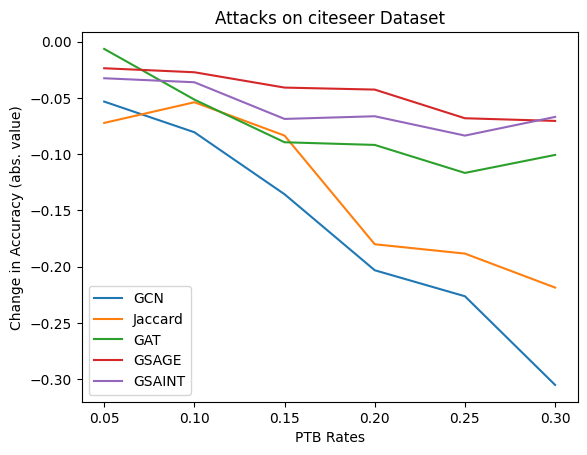

In [28]:
# Plotting
plt.plot(ptb_rates, gcn_results, label="GCN")
plt.plot(ptb_rates, jaccard_results, label="Jaccard")
plt.plot(ptb_rates, gat_results, label="GAT")
plt.plot(ptb_rates, gsage_results, label="GSAGE")
plt.plot(ptb_rates, gsaint_results, label="GSAINT")

plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy (abs. value)')
plt.title(f'Attacks on {dataset} Dataset')
plt.legend()

output_path = f"./data/{dataset}_graph.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [29]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/{dataset}/gcn_results.npy',
    f'./data-arrays/{dataset}/gat_results.npy',
    f'./data-arrays/{dataset}/jaccard_results.npy',
    f'./data-arrays/{dataset}/gsage_results.npy',
    f'./data-arrays/{dataset}/gsaint_results.npy',
    f'./data-arrays/{dataset}/ptb_rates.npy'
]

results = [
    np.array(gcn_results),
    np.array(gat_results),
    np.array(jaccard_results),
    np.array(gsage_results),
    np.array(gsaint_results),
    np.array(ptb_rates)
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)